In [11]:
import numpy as np
import pandas as pd
from ucimlrepo import fetch_ucirepo  
from sklearn.model_selection import cross_val_score, StratifiedKFold,KFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from itertools import product
sns.set_theme()
sns.set_style("whitegrid")

In [12]:
def make_tree(X_train, y_train, X_test, y_test, feature_names, class_names, params, stratify=True, balanced_weight=False, scoring='accuracy', plot=True, class_rep_print=True):
    if params is None:
        params = {
            'criterion': 'gini'}
    if stratify:
        cv = StratifiedKFold(n_splits=5, shuffle=True)
    else:
        cv = KFold(n_splits=5, shuffle=True)
    if balanced_weight:
        clf = DecisionTreeClassifier(**params, class_weight='balanced')
    else:
        clf = DecisionTreeClassifier(**params)
    
    pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('clf', clf)
    ])
    
    #print(f"Classifier params: {clf.get_params()}")
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring=scoring)
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    class_report = classification_report(y_test, y_pred, zero_division=0)
    if class_rep_print:
        print(class_report)
    if plot:
        plt.figure(figsize=(20, 10))
        plot_tree(pipe.named_steps['clf'], feature_names=feature_names, class_names=class_names, filled=True, max_depth=3)
        plt.show()
    return scores, scores.mean(), scores.std()

# Glass

In [13]:
glass_identification = fetch_ucirepo(id=42) 
X_glass = glass_identification.data.features
y_glass = glass_identification.data.targets
df_glass = pd.concat([X_glass, y_glass], axis=1)
X_glass = df_glass.drop(columns=['Type_of_glass'])
y_glass = df_glass['Type_of_glass']

X_train_glass, X_test_glass, y_train_glass, y_test_glass = train_test_split(X_glass, y_glass, test_size=0.2, stratify=y_glass)
unique_classes_glass = y_glass.unique()

## Zwykły klasyfikator

              precision    recall  f1-score   support

           1       0.75      0.86      0.80        14
           2       0.77      0.67      0.71        15
           3       0.50      0.33      0.40         3
           5       0.75      1.00      0.86         3
           6       0.50      0.50      0.50         2
           7       1.00      1.00      1.00         6

    accuracy                           0.77        43
   macro avg       0.71      0.73      0.71        43
weighted avg       0.76      0.77      0.76        43



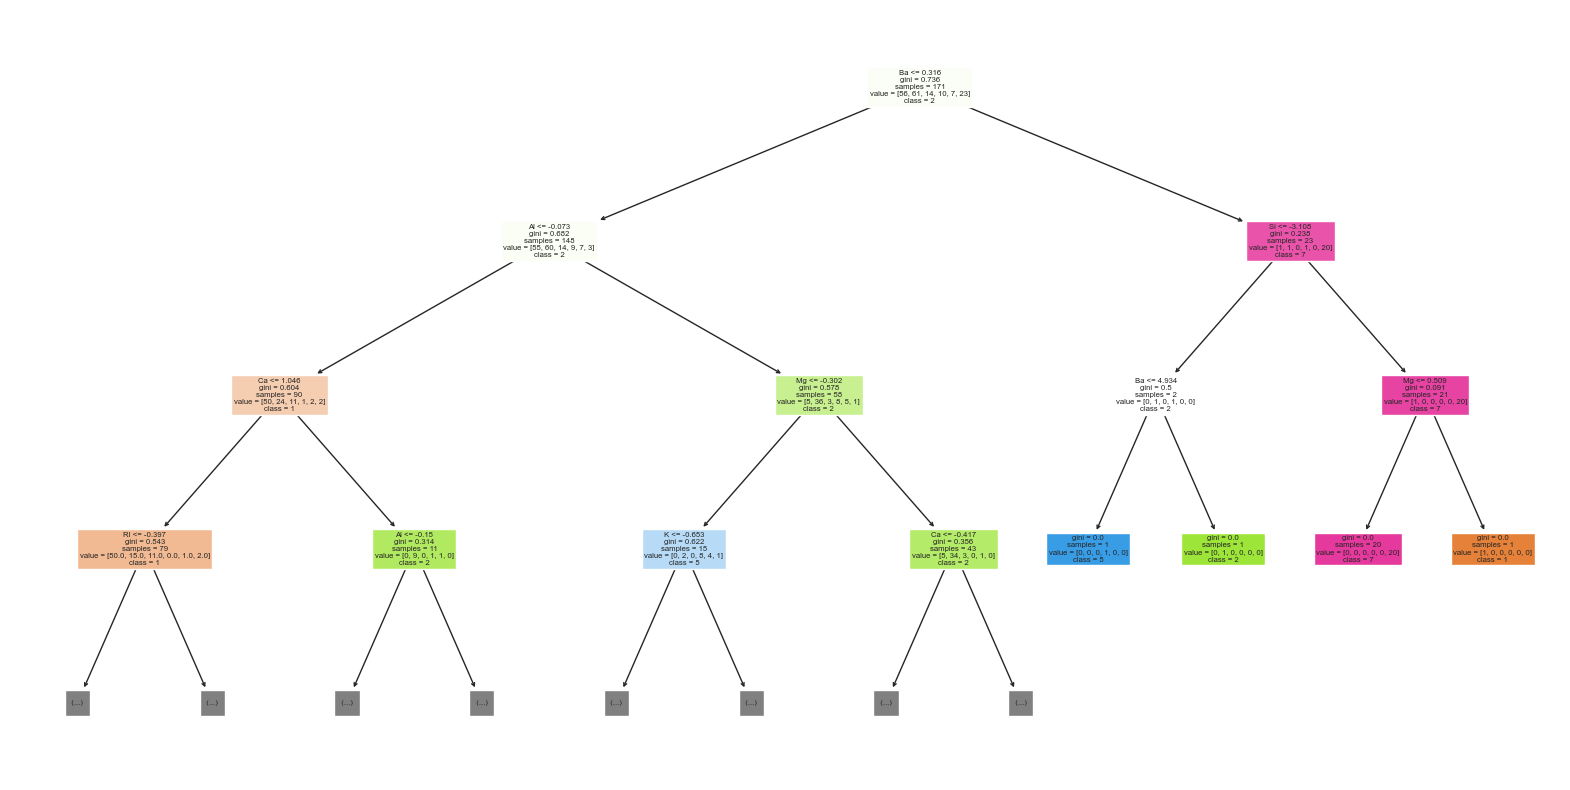

In [14]:
scores_no_stratify, _, _ = make_tree(X_train_glass, y_train_glass, X_test_glass, y_test_glass, feature_names=X_glass.columns, class_names=[str(c) for c in unique_classes_glass], params=None, stratify=False, scoring='f1_macro', plot=True)

In [15]:
scores_stratify, _, _ = make_tree(X_train_glass, y_train_glass, X_test_glass, y_test_glass, feature_names=X_glass.columns, class_names=[str(c) for c in unique_classes_glass], params=None, stratify=True, scoring='f1_macro', plot=False)

              precision    recall  f1-score   support

           1       0.75      0.86      0.80        14
           2       0.79      0.73      0.76        15
           3       0.50      0.33      0.40         3
           5       1.00      1.00      1.00         3
           6       1.00      0.50      0.67         2
           7       0.86      1.00      0.92         6

    accuracy                           0.79        43
   macro avg       0.82      0.74      0.76        43
weighted avg       0.79      0.79      0.78        43



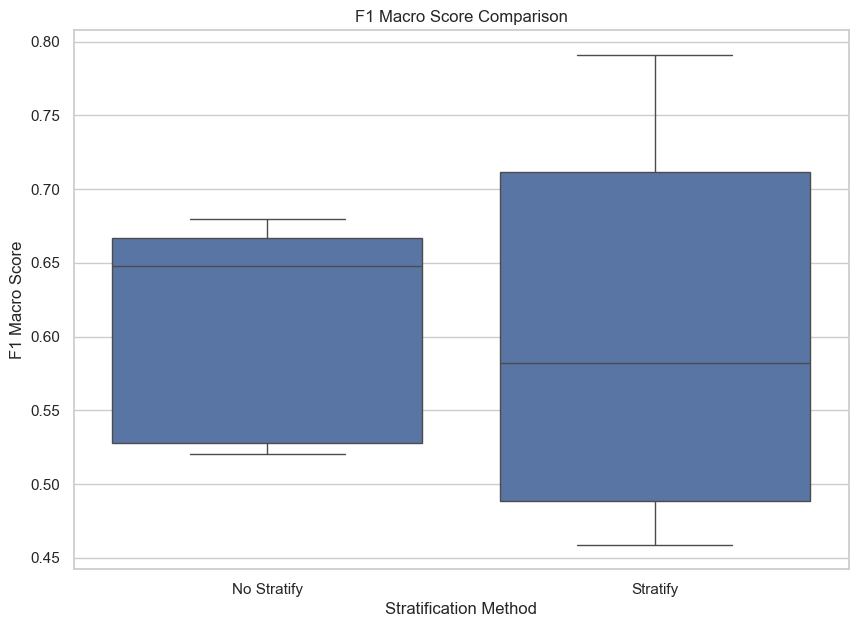

In [16]:
data = pd.DataFrame({
    'Stratification Method': ['No Stratify'] * len(scores_no_stratify) + ['Stratify'] * len(scores_stratify),
    'F1 Macro Score': np.concatenate([scores_no_stratify, scores_stratify])
})

plt.figure(figsize=(10, 7))
sns.boxplot(x='Stratification Method', y='F1 Macro Score', data=data)
plt.title('F1 Macro Score Comparison')
plt.show()

## Eksperymenty

In [17]:
depths = range(2, 11)
strat_opts = [True, False]

results = []

for max_depth, strat in product(depths, strat_opts):
    _, mean, std = make_tree(
        X_train_glass, y_train_glass,
        X_test_glass,  y_test_glass,
        feature_names=X_glass.columns,
        class_names=[str(c) for c in unique_classes_glass],
        params={"criterion": "gini", "max_depth": max_depth},
        stratify=strat,
        scoring="f1_macro",
        plot=False,
        class_rep_print=False,
    )
    results.append(
        dict(max_depth=max_depth,
             stratified=strat,
             mean=mean,
             std=std)
    )

df = pd.DataFrame(results)

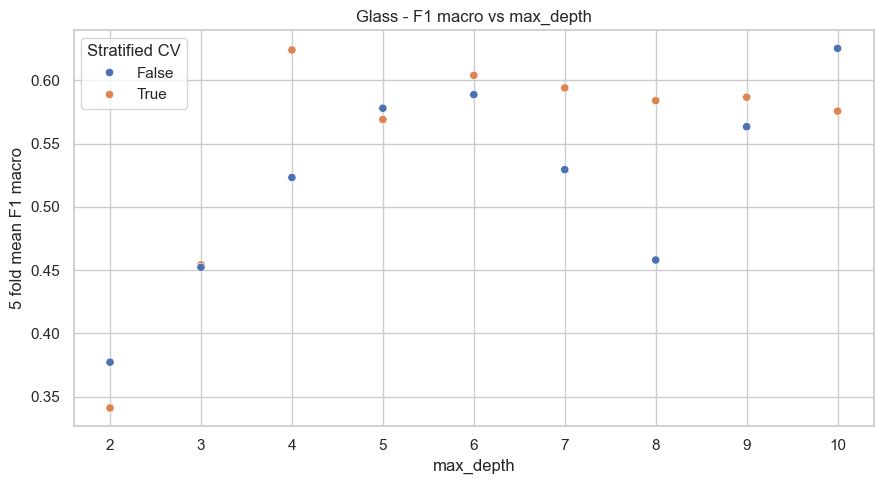

In [18]:
plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=df,
    x="max_depth",
    y="mean",
    hue="stratified",
    marker="o",
)
plt.title("Glass - F1 macro vs max_depth")
plt.xlabel("max_depth")
plt.ylabel("5 fold mean F1 macro")
plt.legend(title="Stratified CV")
plt.tight_layout()
plt.show()

In [19]:
min_samples_leaf = [1,2,3,4,5,6,7,8,9,10]
strat_opts = [True, False]
results_min_samples_leaf = []

for min_samples, strat in product(min_samples_leaf, strat_opts):
    _, mean, std = make_tree(
        X_train_glass, y_train_glass,
        X_test_glass,  y_test_glass,
        feature_names=X_glass.columns,
        class_names=[str(c) for c in unique_classes_glass],
        params={"criterion": "gini", "min_samples_leaf": min_samples},
        stratify=strat,
        scoring="f1_macro",
        plot=False,
        class_rep_print=False,
    )
    results_min_samples_leaf.append(
        dict(min_samples=min_samples,
             stratified=strat,
             mean=mean,
             std=std)
    )
    
df_min_samples_leaf = pd.DataFrame(results_min_samples_leaf)

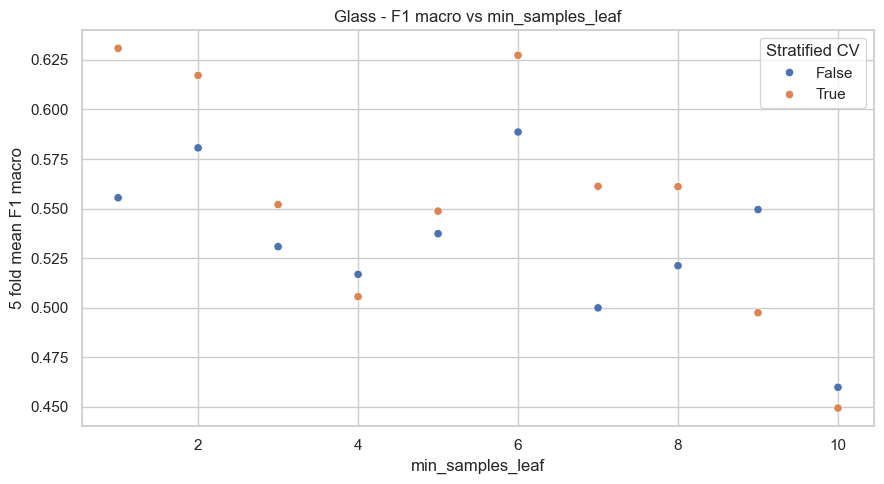

In [20]:
plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=df_min_samples_leaf,
    x="min_samples",
    y="mean",
    hue="stratified",
    marker="o",
)
plt.title("Glass - F1 macro vs min_samples_leaf")
plt.xlabel("min_samples_leaf")
plt.ylabel("5 fold mean F1 macro")
plt.legend(title="Stratified CV")
plt.tight_layout()
plt.show()

Wpływa na *złożoność* drzewa, im większa minimalna liczba próbek w liściu, tym prostrze drzewo, bo nie moze tworzyć wąskich, dopasowanych rozgałęzień.

In [21]:
cpp_alpha = np.arange(0.0, 1.0, 0.01)
strat_opts = [True, False]
results_cpp_alpha = []

for alpha, strat in product(cpp_alpha, strat_opts):
    _, mean, std = make_tree(
        X_train_glass, y_train_glass,
        X_test_glass,  y_test_glass,
        feature_names=X_glass.columns,
        class_names=[str(c) for c in unique_classes_glass],
        params={"criterion": "gini", "ccp_alpha": alpha},
        stratify=strat,
        scoring="f1_macro",
        plot=False,
        class_rep_print=False,
    )
    results_cpp_alpha.append(
        dict(ccp_alpha=alpha,
             stratified=strat,
             mean=mean,
             std=std)
    )
    
df_cpp_alpha = pd.DataFrame(results_cpp_alpha)

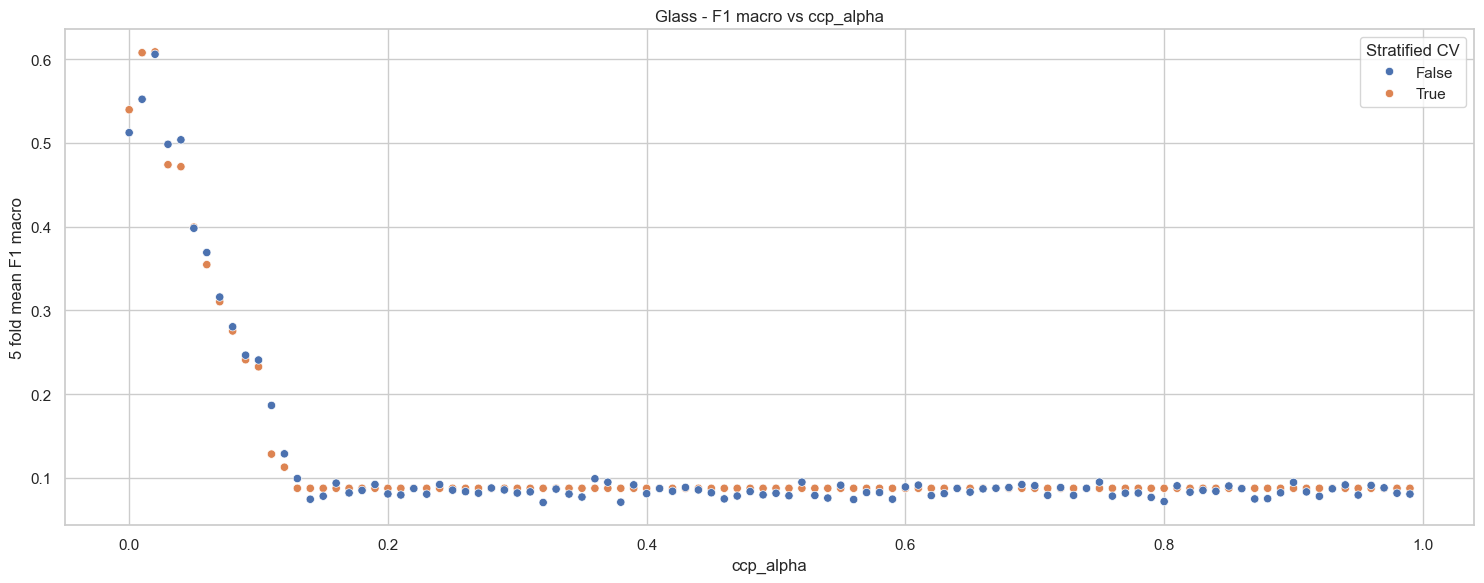

In [22]:
plt.figure(figsize=(15, 6))
sns.scatterplot(
    data=df_cpp_alpha,
    x="ccp_alpha",
    y="mean",
    hue="stratified",
    marker="o",
)
plt.title("Glass - F1 macro vs ccp_alpha")
plt.xlabel("ccp_alpha")
plt.ylabel("5 fold mean F1 macro")
plt.legend(title="Stratified CV")
plt.tight_layout()
plt.show()

Trenuje się pełne drzewo, a potem oblicza się koszt złożności i usuwa te gałęzie, które zwiększają koszt złożności.

## Wybrane drzewa

              precision    recall  f1-score   support

           1       0.72      0.93      0.81        14
           2       0.83      0.67      0.74        15
           3       0.50      0.33      0.40         3
           5       0.75      1.00      0.86         3
           6       1.00      0.50      0.67         2
           7       1.00      1.00      1.00         6

    accuracy                           0.79        43
   macro avg       0.80      0.74      0.75        43
weighted avg       0.80      0.79      0.78        43



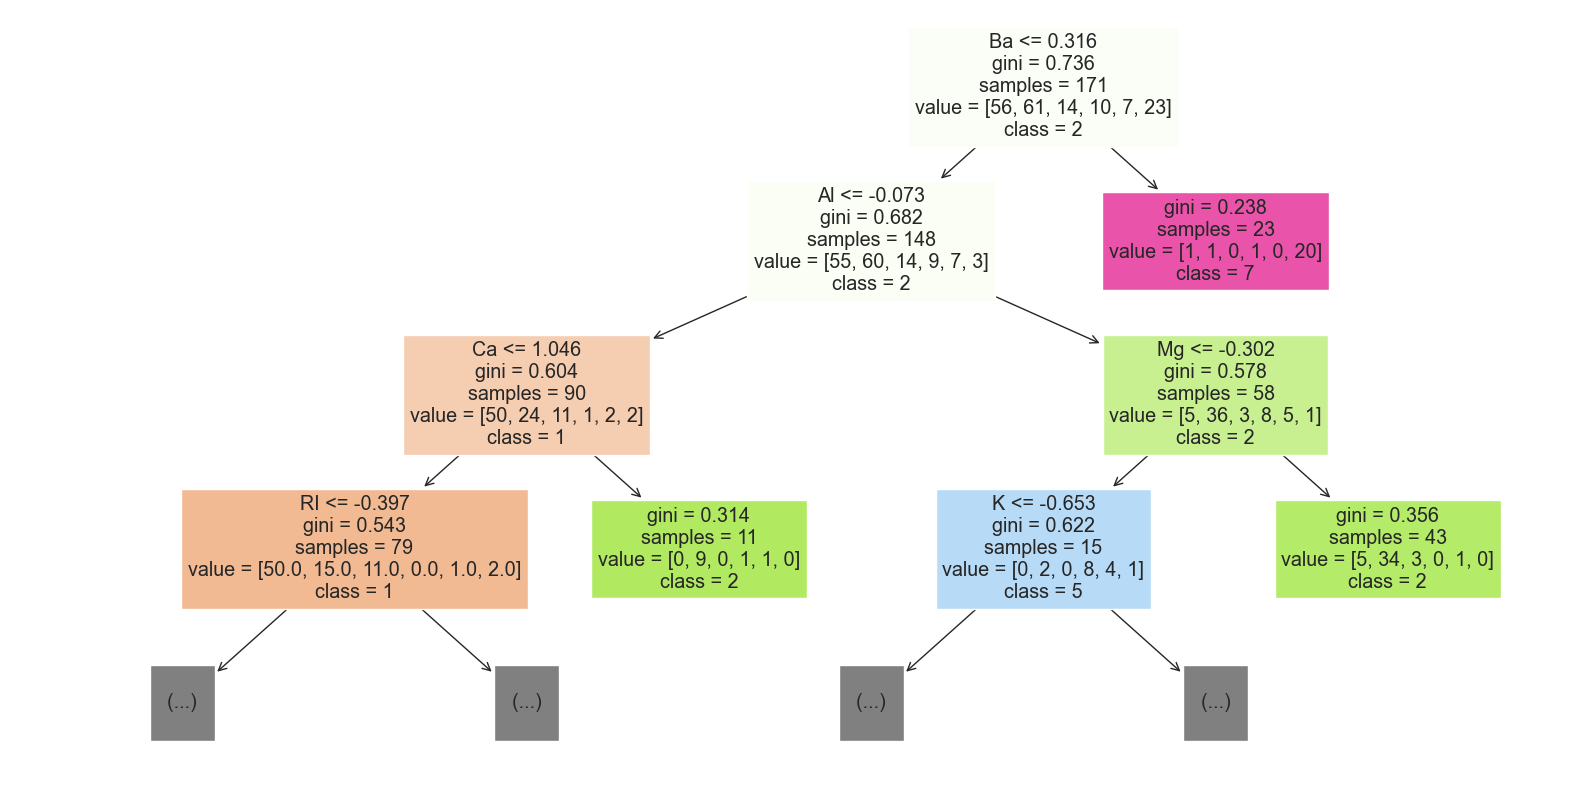

              precision    recall  f1-score   support

           1       0.00      0.00      0.00        14
           2       0.35      1.00      0.52        15
           3       0.00      0.00      0.00         3
           5       0.00      0.00      0.00         3
           6       0.00      0.00      0.00         2
           7       0.00      0.00      0.00         6

    accuracy                           0.35        43
   macro avg       0.06      0.17      0.09        43
weighted avg       0.12      0.35      0.18        43



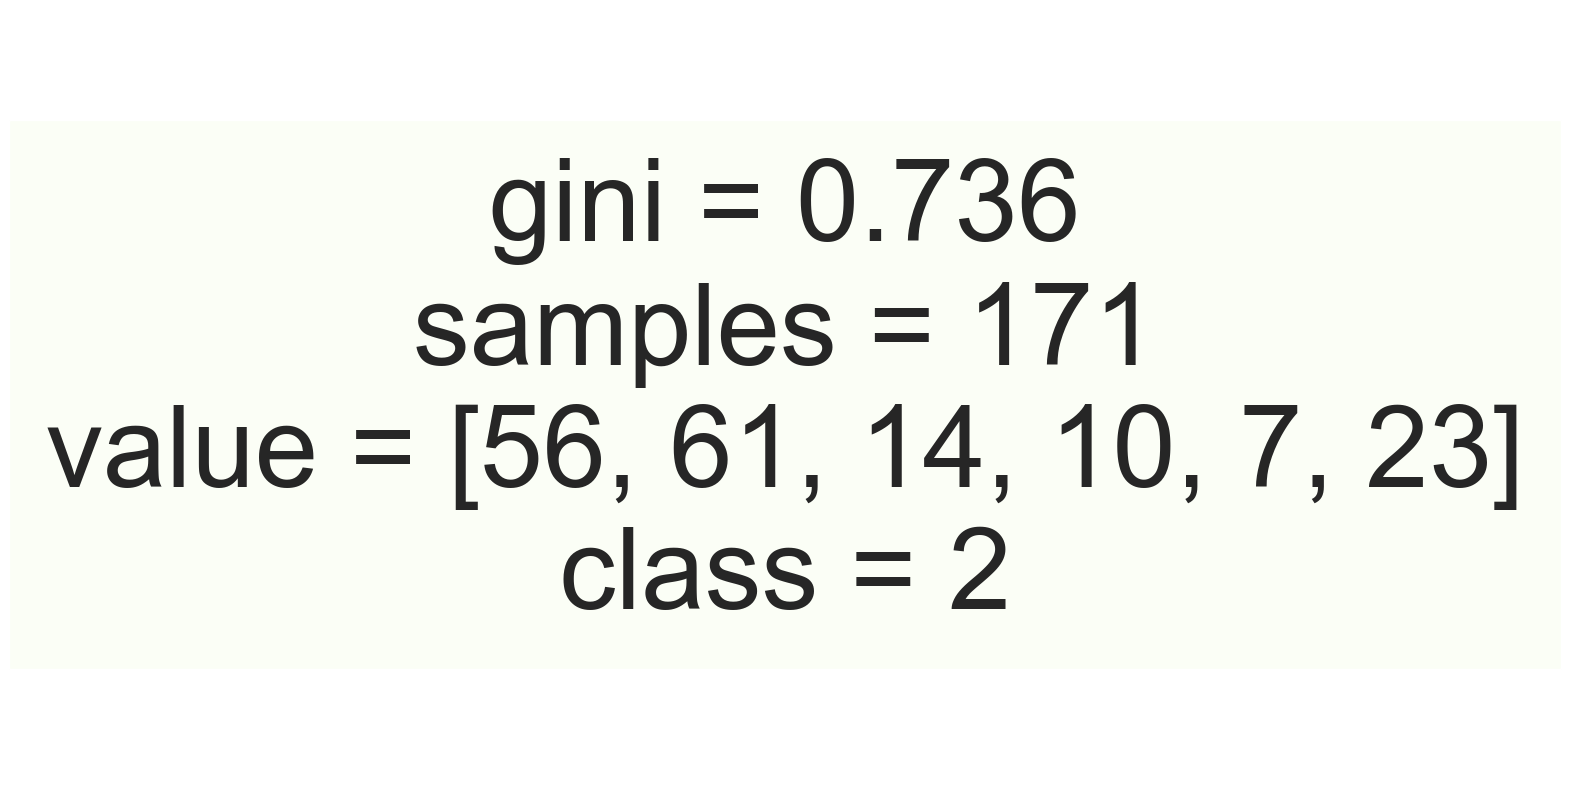

(array([0.09027778, 0.08695652, 0.08695652, 0.08695652, 0.08695652]),
 0.08762077294685991,
 0.0013285024154589375)

In [23]:
make_tree(X_train_glass, y_train_glass, X_test_glass, y_test_glass, feature_names=X_glass.columns, class_names=[str(c) for c in unique_classes_glass], params={"criterion": "gini", 'ccp_alpha':0.02}, stratify=True, scoring='f1_macro', plot=True, class_rep_print=True)
make_tree(X_train_glass, y_train_glass, X_test_glass, y_test_glass, feature_names=X_glass.columns, class_names=[str(c) for c in unique_classes_glass], params={"criterion": "gini", 'ccp_alpha':0.99}, stratify=True, scoring='f1_macro', plot=True, class_rep_print=True)

# PCB

In [24]:
polish_companies = fetch_ucirepo(id=365)
X_pcb = polish_companies.data.features
y_pcb = polish_companies.data.targets
df_pcb = pd.concat([X_pcb, y_pcb], axis=1)
X_pcb = df_pcb.drop(columns=['class'])
y_pcb = df_pcb['class']

X_train_pcb, X_test_pcb, y_train_pcb, y_test_pcb = train_test_split(X_pcb, y_pcb, test_size=0.2, stratify=y_pcb)
unique_classes_pcb = np.sort(y_pcb.unique())

## Zwykły klasyfikator

              precision    recall  f1-score   support

           0       0.98      0.97      0.97      8263
           1       0.48      0.51      0.49       418

    accuracy                           0.95      8681
   macro avg       0.73      0.74      0.73      8681
weighted avg       0.95      0.95      0.95      8681



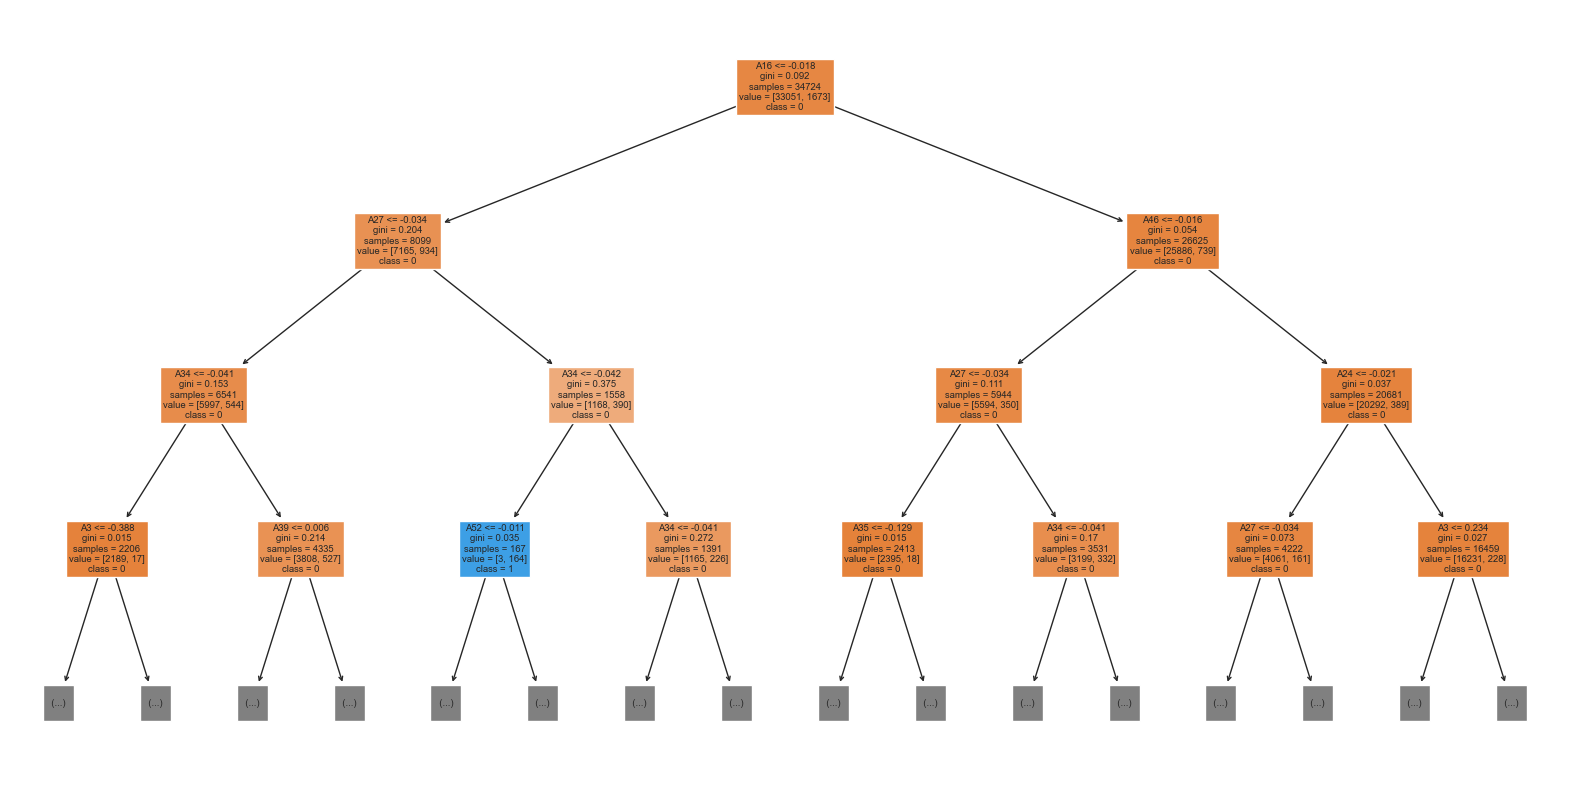

              precision    recall  f1-score   support

           0       0.98      0.97      0.98      8263
           1       0.51      0.53      0.52       418

    accuracy                           0.95      8681
   macro avg       0.75      0.75      0.75      8681
weighted avg       0.95      0.95      0.95      8681



In [25]:
scores_no_statify_pcb, _, _ = make_tree(X_train_pcb, y_train_pcb, X_test_pcb, y_test_pcb, feature_names=X_pcb.columns, class_names=[str(c) for c in unique_classes_pcb], params=None, stratify=False, scoring='f1', plot=True)
scores_stratify_pcb, _, _ = make_tree(X_train_pcb, y_train_pcb, X_test_pcb, y_test_pcb, feature_names=X_pcb.columns, class_names=[str(c) for c in unique_classes_pcb], params=None, stratify=True, scoring='f1', plot=False)

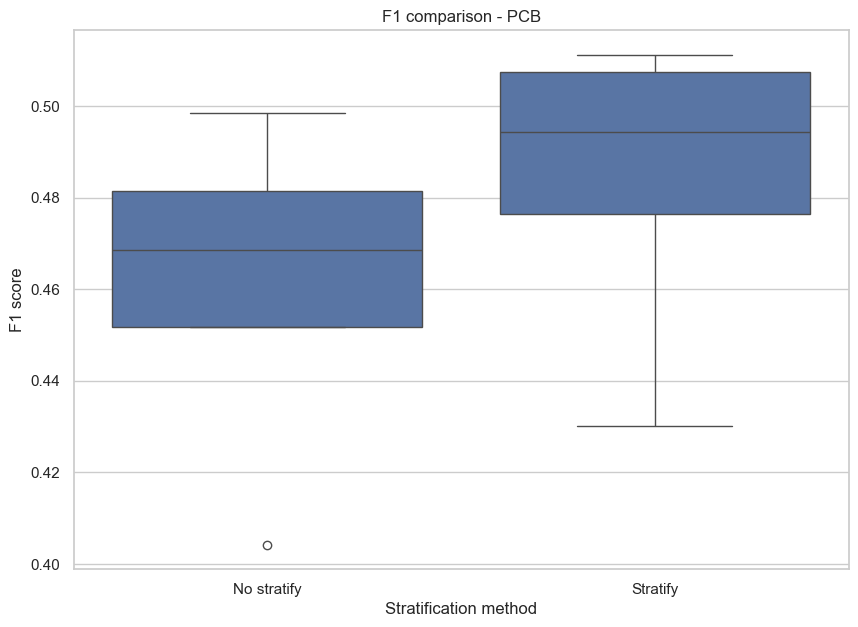

In [26]:
data_pcb = pd.DataFrame({
    'Stratification method': ['No stratify'] * len(scores_no_statify_pcb) + ['Stratify'] * len(scores_stratify_pcb),
    'F1 score': np.concatenate([scores_no_statify_pcb, scores_stratify_pcb])
})
plt.figure(figsize=(10, 7))
sns.boxplot(x='Stratification method', y='F1 score', data=data_pcb)
plt.title('F1 comparison - PCB')
plt.show()

## Eksperymenty

In [27]:
depths_pcb = range(2, 11)
strat_opts_pcb = [True, False]
results_pcb = []

for max_depth, strat in product(depths_pcb, strat_opts_pcb):
    _, mean, std = make_tree(
        X_train_pcb, y_train_pcb,
        X_test_pcb,  y_test_pcb,
        feature_names=X_pcb.columns,
        class_names=[str(c) for c in unique_classes_pcb],
        params={"criterion": "gini", "max_depth": max_depth},
        stratify=strat,
        scoring="f1",
        plot=False,
        class_rep_print=False,
    )
    results_pcb.append(
        dict(max_depth=max_depth,
             stratified=strat,
             mean=mean,
             std=std)
    )
df_pcb_depths = pd.DataFrame(results_pcb)

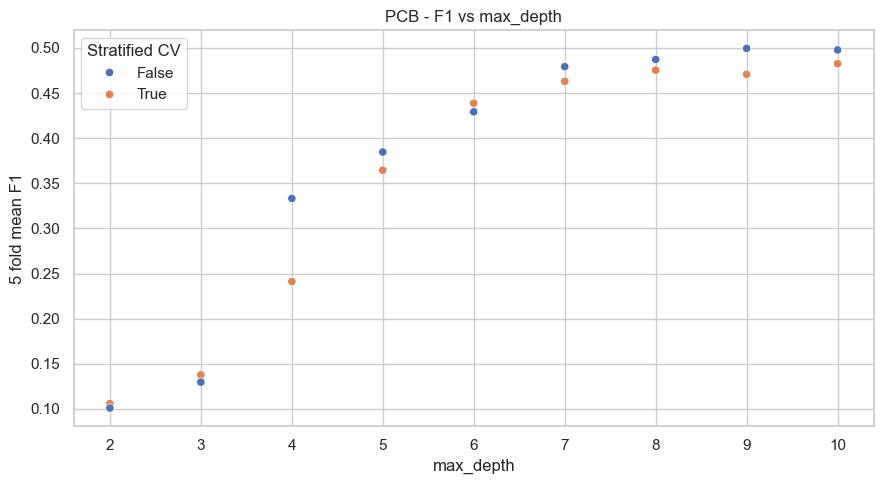

In [28]:
plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=df_pcb_depths,
    x="max_depth",
    y="mean",
    hue="stratified",
    marker="o",
)
plt.title("PCB - F1 vs max_depth")
plt.xlabel("max_depth")
plt.ylabel("5 fold mean F1")
plt.legend(title="Stratified CV")
plt.tight_layout()
plt.show()

In [29]:
min_samples_leaf_pcb = [1,2,3,4,5,6,7,8,9,10]
strat_opts_pcb = [True, False]
results_min_samples_leaf_pcb = []

for min_samples, strat in product(min_samples_leaf_pcb, strat_opts_pcb):
    _, mean, std = make_tree(
        X_train_pcb, y_train_pcb,
        X_test_pcb,  y_test_pcb,
        feature_names=X_pcb.columns,
        class_names=[str(c) for c in unique_classes_pcb],
        params={"criterion": "gini", "min_samples_leaf": min_samples},
        stratify=strat,
        scoring="f1",
        plot=False,
        class_rep_print=False,
    )
    results_min_samples_leaf_pcb.append(
        dict(min_samples=min_samples,
             stratified=strat,
             mean=mean,
             std=std)
    )
    
df_min_samples_leaf_pcb = pd.DataFrame(results_min_samples_leaf_pcb)

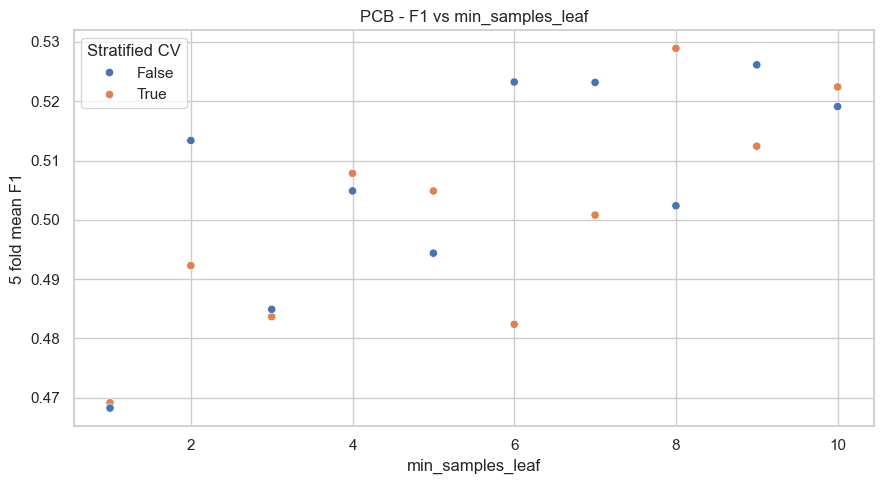

In [30]:
plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=df_min_samples_leaf_pcb,
    x="min_samples",
    y="mean",
    hue="stratified",
    marker="o",
)
plt.title("PCB - F1 vs min_samples_leaf")
plt.xlabel("min_samples_leaf")
plt.ylabel("5 fold mean F1")
plt.legend(title="Stratified CV")
plt.tight_layout()
plt.show()

In [31]:
cpp_alpha_pcb = np.arange(0.0, 1.0, 0.1)
strat_opts_pcb = [True, False]
results_cpp_alpha_pcb = []

for alpha, strat in product(cpp_alpha_pcb, strat_opts_pcb):
    _, mean, std = make_tree(
        X_train_pcb, y_train_pcb,
        X_test_pcb,  y_test_pcb,
        feature_names=X_pcb.columns,
        class_names=[str(c) for c in unique_classes_pcb],
        params={"criterion": "gini", "ccp_alpha": alpha},
        stratify=strat,
        scoring="f1",
        plot=False,
        class_rep_print=False,
    )
    results_cpp_alpha_pcb.append(
        dict(ccp_alpha=alpha,
             stratified=strat,
             mean=mean,
             std=std)
    )
    
df_cpp_alpha_pcb = pd.DataFrame(results_cpp_alpha_pcb)

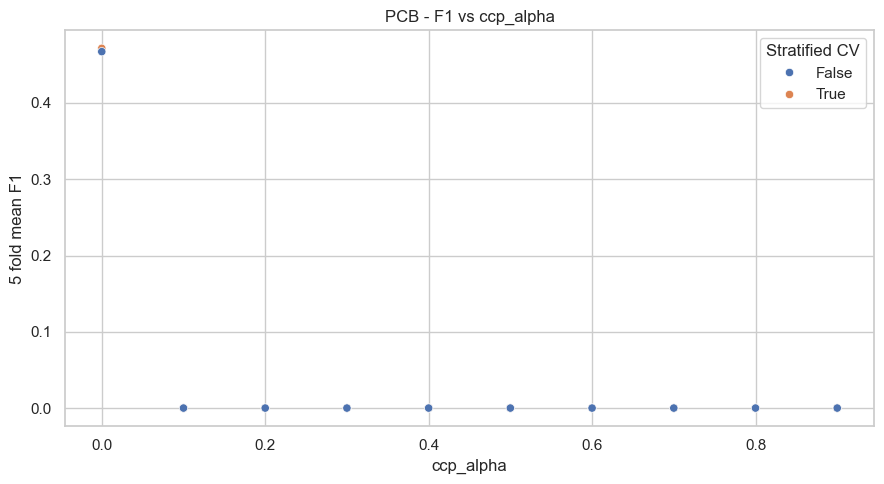

In [32]:
plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=df_cpp_alpha_pcb,
    x="ccp_alpha",
    y="mean",
    hue="stratified",
    marker="o",
)
plt.title("PCB - F1 vs ccp_alpha")
plt.xlabel("ccp_alpha")
plt.ylabel("5 fold mean F1")
plt.legend(title="Stratified CV")
plt.tight_layout()
plt.show()

## Wybrane drzewa

              precision    recall  f1-score   support

           0       0.95      1.00      0.98      8263
           1       0.00      0.00      0.00       418

    accuracy                           0.95      8681
   macro avg       0.48      0.50      0.49      8681
weighted avg       0.91      0.95      0.93      8681



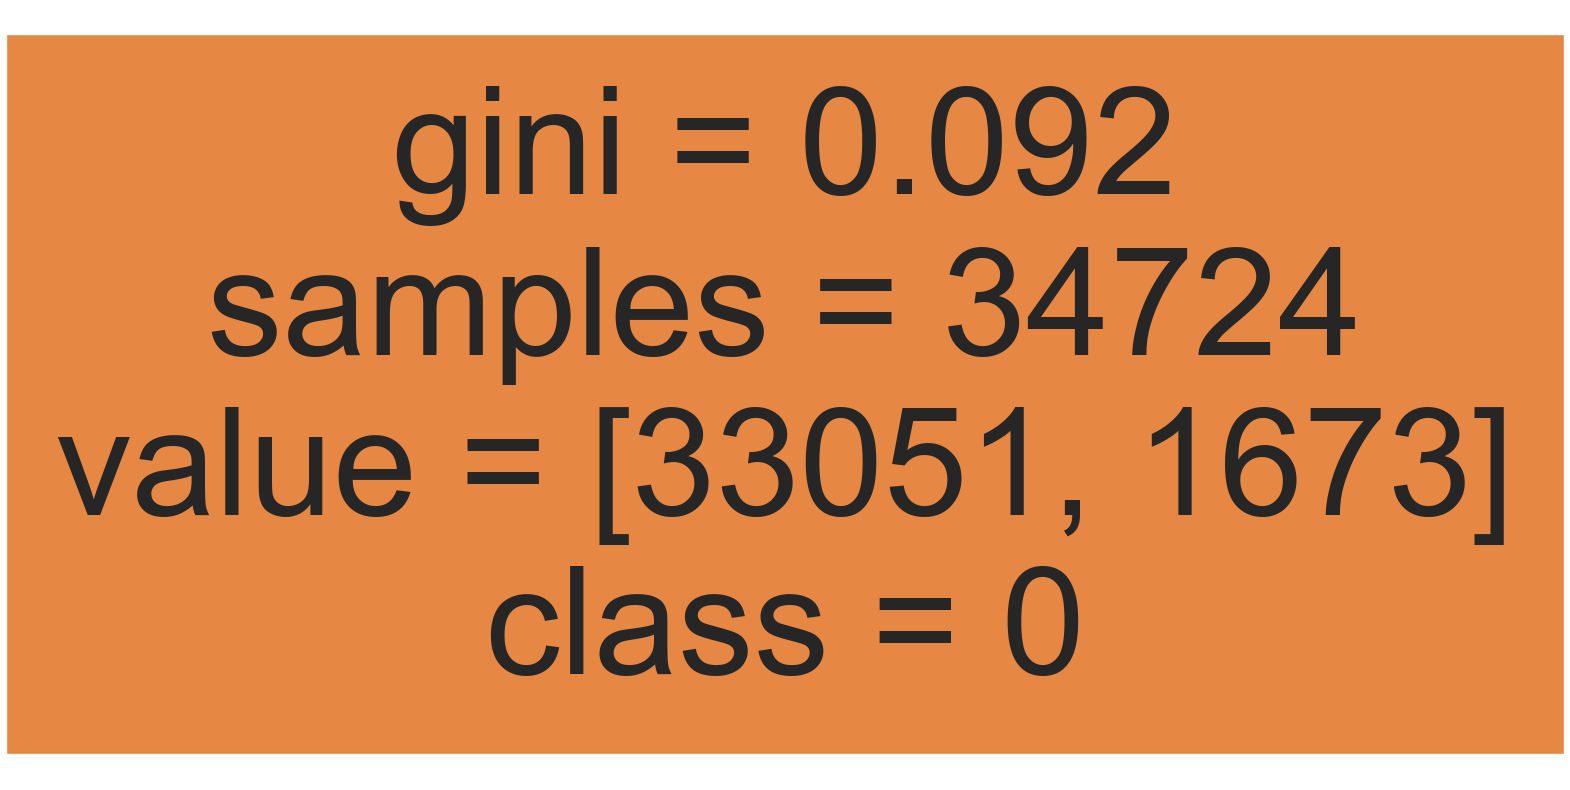

              precision    recall  f1-score   support

           0       0.95      1.00      0.98      8263
           1       0.00      0.00      0.00       418

    accuracy                           0.95      8681
   macro avg       0.48      0.50      0.49      8681
weighted avg       0.91      0.95      0.93      8681



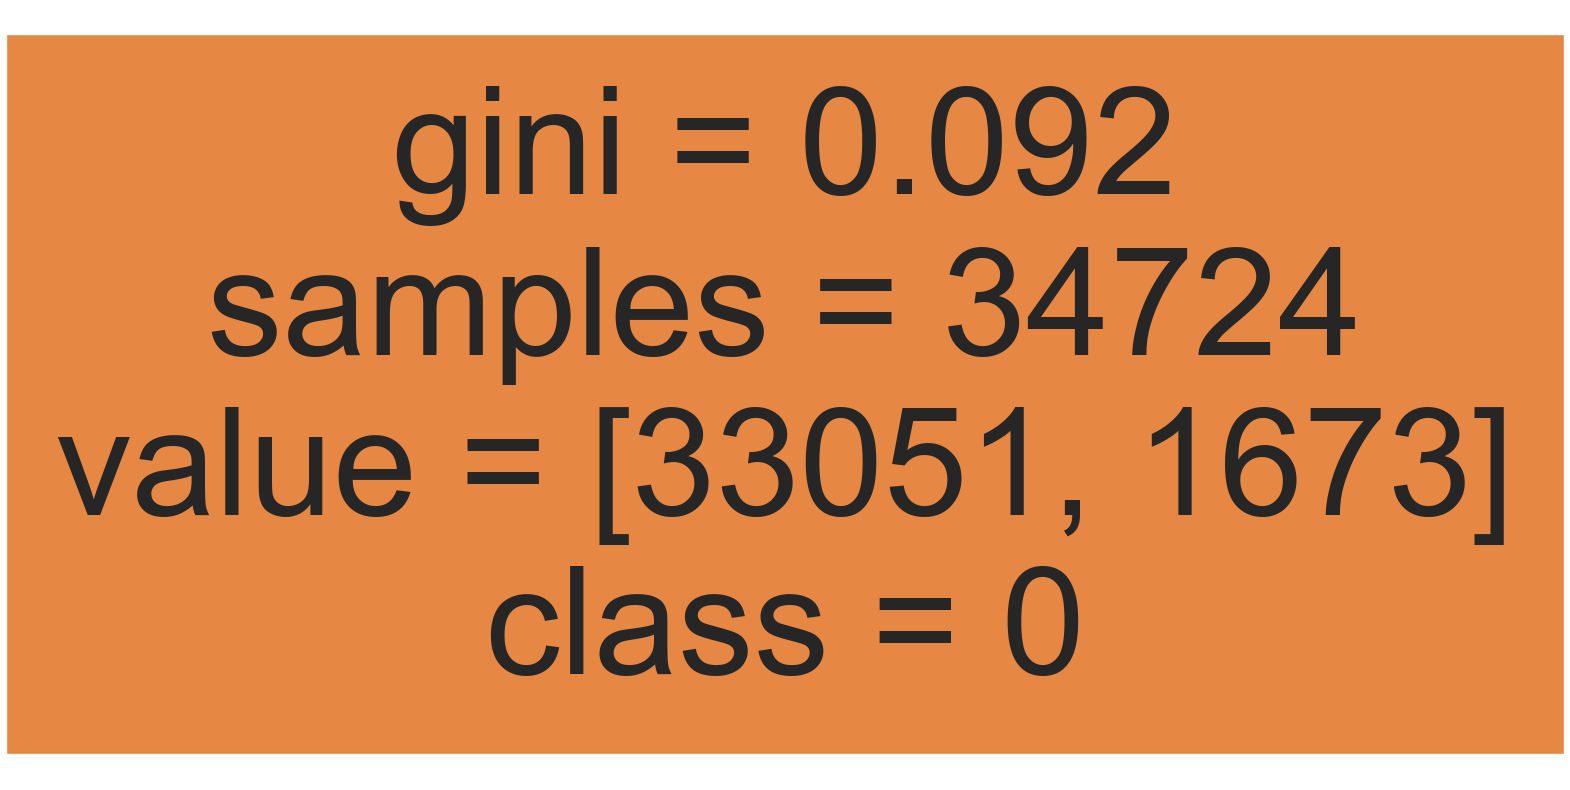

(array([0., 0., 0., 0., 0.]), 0.0, 0.0)

In [33]:
make_tree(X_train_pcb, y_train_pcb, X_test_pcb, y_test_pcb, feature_names=X_pcb.columns, class_names=[str(c) for c in unique_classes_pcb], params={"criterion": "gini", 'ccp_alpha':0.02}, stratify=True, scoring='f1', plot=True, class_rep_print=True)
make_tree(X_train_pcb, y_train_pcb, X_test_pcb, y_test_pcb, feature_names=X_pcb.columns, class_names=[str(c) for c in unique_classes_pcb], params={"criterion": "gini", 'ccp_alpha':0.99}, stratify=True, scoring='f1', plot=True, class_rep_print=True)

## Użycie hiperparametru wagi klasy

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      8263
           1       0.54      0.53      0.53       418

    accuracy                           0.96      8681
   macro avg       0.76      0.75      0.76      8681
weighted avg       0.96      0.96      0.96      8681



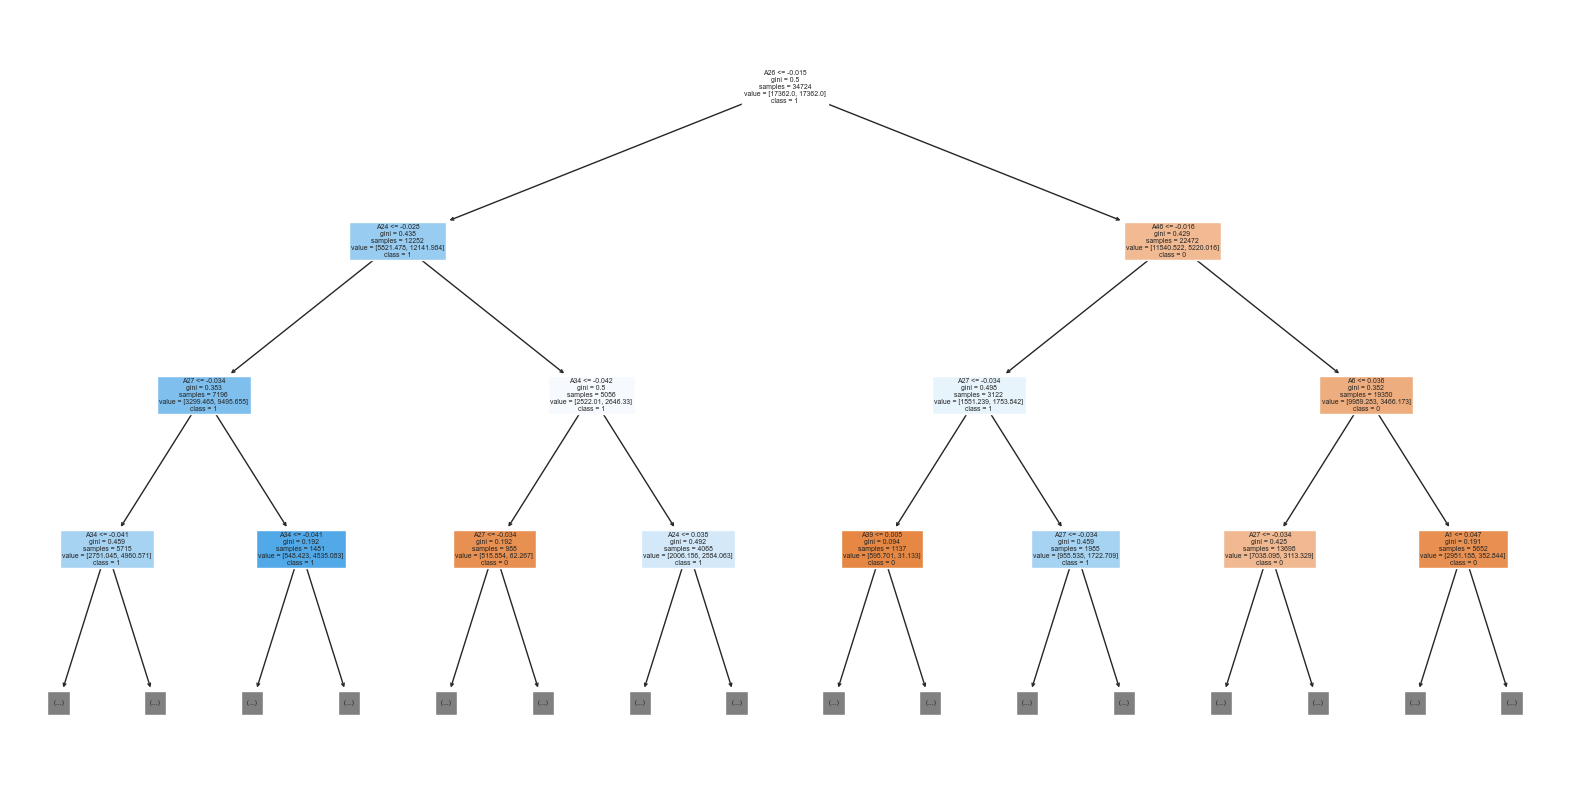

              precision    recall  f1-score   support

           0       0.98      0.97      0.97      8263
           1       0.50      0.51      0.51       418

    accuracy                           0.95      8681
   macro avg       0.74      0.74      0.74      8681
weighted avg       0.95      0.95      0.95      8681



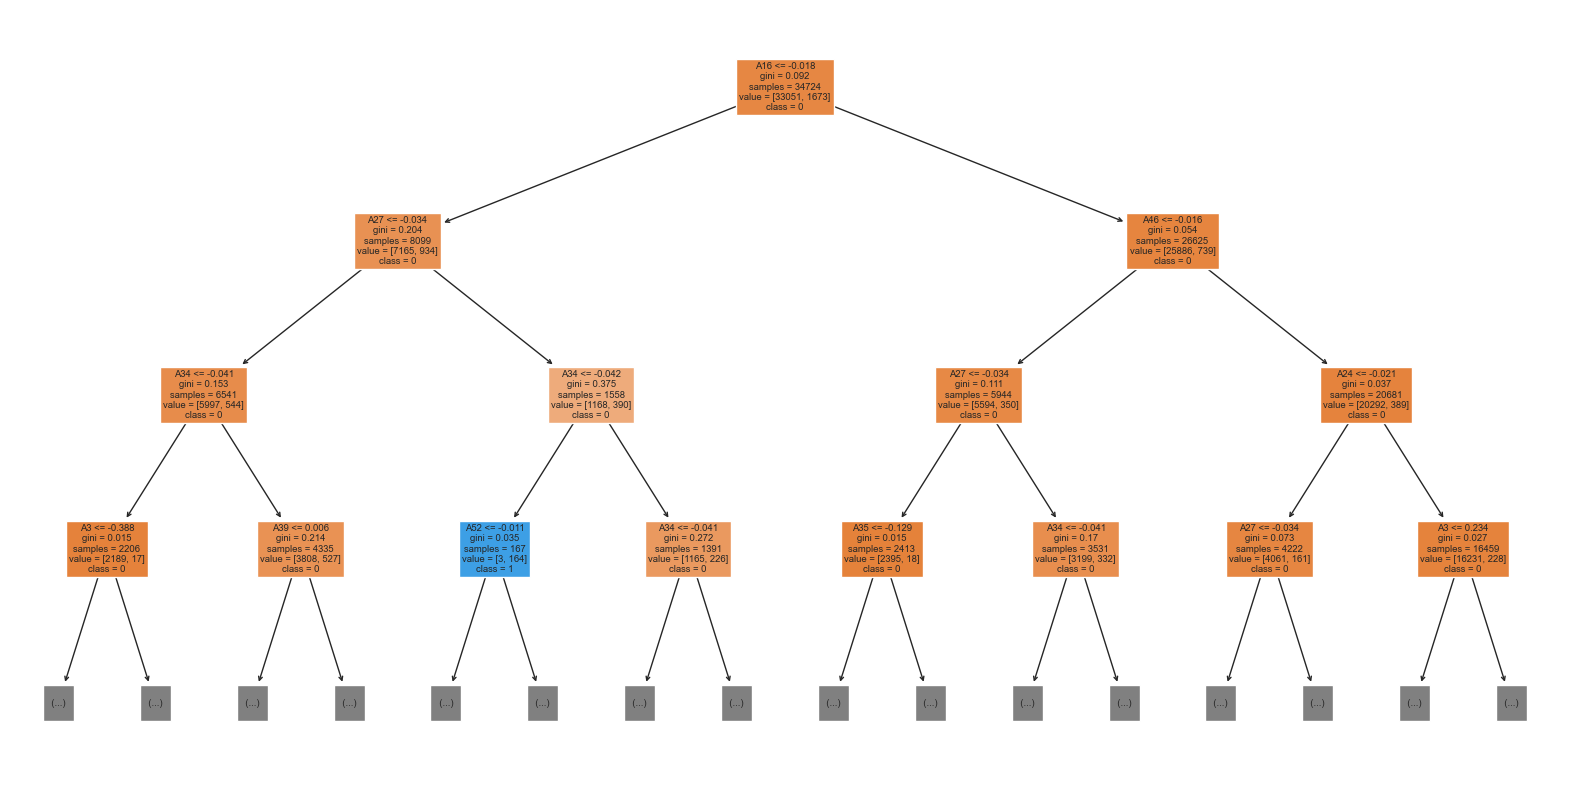

In [34]:
scores_balanced_weight, _, _ = make_tree(X_train_pcb, y_train_pcb, X_test_pcb, y_test_pcb, feature_names=X_pcb.columns, class_names=[str(c) for c in unique_classes_pcb], params={"criterion": "gini"}, stratify=True, balanced_weight=True, scoring='f1', plot=True, class_rep_print=True)
scores_no_balanced_weight, _, _ = make_tree(X_train_pcb, y_train_pcb, X_test_pcb, y_test_pcb, feature_names=X_pcb.columns, class_names=[str(c) for c in unique_classes_pcb], params={"criterion": "gini"}, stratify=True, balanced_weight=False, scoring='f1', plot=True, class_rep_print=True)

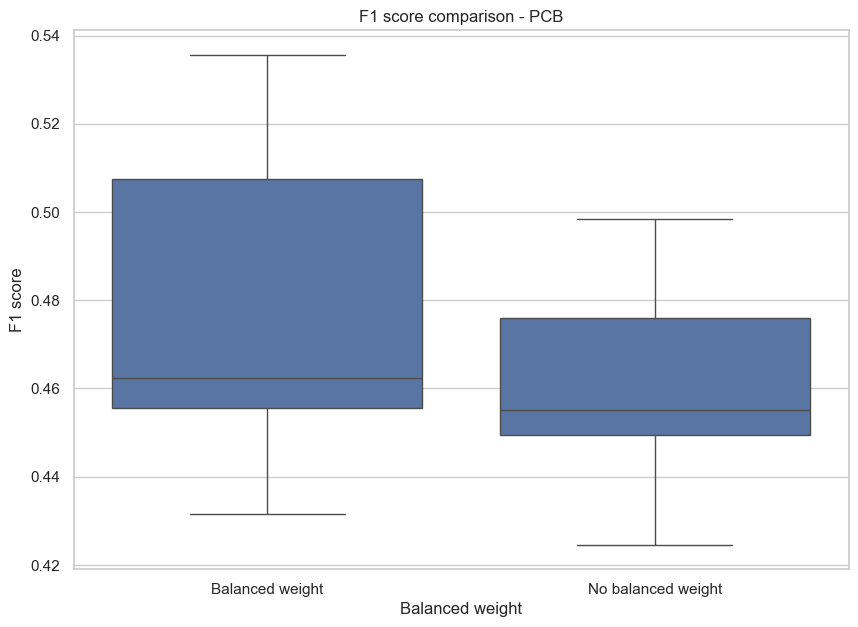

In [35]:
data_balanced_weight = pd.DataFrame({
    'Balanced weight': ['Balanced weight'] * len(scores_balanced_weight) + ['No balanced weight'] * len(scores_no_balanced_weight),
    'F1 score': np.concatenate([scores_balanced_weight, scores_no_balanced_weight])
})
plt.figure(figsize=(10, 7))
sns.boxplot(x='Balanced weight', y='F1 score', data=data_balanced_weight)
plt.title('F1 score comparison - PCB')
plt.show()

# Pytania pomocnicze

- Co znajduje się w liściach drzewa?

W liściach drzewa decyzyjnego znajdują się ostateczne decyzje klasyfikacyjne - tzn. przypisane klasy etykujące próbki, które trafiły do danego liścia. Zwykle podana jest także liczba próbek w liściu oraz zakład klas, a także miara czystości, np. wskaźnik Giniego.

- Czy przycinanie drzewa (pruning) jest potrzebne? Na czym polega ten proces?

Tak przycinanie drzewa, jest potrzebne, ponieważ zapobiega przeuczeniu (overfittingowi) modelu. Proces polega na usunięciu gałęzi drzewa, które nie przyczyniają się istotnie do poprawy skuteczności klasyfikacji. W CART używa się często parametru (cost-complexity pruning), które kontroluje kompromis między wielkością drzewa a jego dokładnością. Im większe `ccp_alpha`, tym silniejsze przycinanie.

- Czy drzewo może być za „duże” lub za „małe”? Co to znaczy?

Za duże drzewo (głębokie, z wieloma liśćmi) może dopasować się zbyt dokładnie do danych treningowych, ucząc się również szumu – czyli przeuczenie.

Za małe drzewo może nie uchwycić złożoności danych, prowadząc do niedouczenia (underfitting).

Ważne jest dobranie odpowiednich hiperparametrów, takich jak max_depth, min_samples_leaf.

- Czy drzewo decyzyjne potrzebuje normalizacji/standaryzacji/dyskretyzacji danych? Dlaczego?

Nie, drzewa decyzyjne nie wymagają normalizacji ani standaryzacji danych, ponieważ działają na zasadzie podziałów warunkowych (np. "feature > wartość"), a nie na podstawie odległości czy rozkładu cech. Także dyskretyzacja nie jest wymagana – drzewa dobrze radzą sobie z danymi numerycznymi i kategorycznymi (po odpowiednim przekształceniu).

- Czy model można przeuczyć? Czym się to objawia?

Tak, drzewo decyzyjne można przeuczyć. Objawia się to wysoką dokładnością (accuracy) na danych treningowych, ale niską na danych testowych. Model nauczył się szczegółów i wyjątków w danych uczących, które nie są reprezentatywne dla ogólnego rozkładu danych.

- Na czym polega wagowanie klas?

Wagowanie klas polega na przypisaniu większego znaczenia rzadziej występującym klasom. Stosuje się to w przypadku niezbalansowanych zbiorów danych, np. gdy jedna klasa dominuje liczebnie. Można to osiągnąć poprzez ustawienie parametru class_weight='balanced' w klasyfikatorze. Dzięki temu drzewo bardziej "przejmuje się" poprawną klasyfikacją mniejszościowych klas.